In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv(
    r"D:\Vehicle_Mileage_Project\data\processed\cleaned_dataset.csv"
)

df.head()

,Vehicle_ID,Manufacturer,Model,Vehicle_Age,Engine_CC,Horsepower,Vehicle_Weight,Transmission,Fuel_Type,Ethanol_Blend,...,Traffic_Level,Temperature,Humidity,Weather,AC_Usage,Driving_Style,Passengers,CO2_Emission_g_km,Fuel_Consumption_L_100km,Mileage_km_per_L
0,V014767,Tata,Nexon,13.0,1000.0,82.0,1307.0,Automatic,Petrol,20.0,...,High,27.0,61.0,Fog,No,Normal,1.0,192.1,5.00,20.02
1,V020736,Toyota,Glanza,8.0,1200.0,98.0,1493.0,Automatic,Petrol,20.0,...,High,30.0,48.0,Fog,Yes,Smooth,3.0,189.2,5.12,19.52
2,V041583,Maruti,Baleno,9.0,1200.0,103.0,1262.0,Automatic,Petrol,20.0,...,Medium,34.0,44.0,Fog,Yes,Aggressive,1.0,197.3,5.55,18.01
3,V042258,Honda,City,14.0,1200.0,95.0,1001.0,Manual,Petrol,10.0,...,High,15.0,53.0,Rain,Yes,Normal,1.0,185.8,5.23,19.12
4,V029600,Tata,Altroz,15.0,1800.0,148.0,1604.0,Manual,Petrol,10.0,...,Medium,24.0,65.0,Fog,Yes,Smooth,1.0,197.7,5.90,16.96


In [3]:
df.shape
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 63973 entries, 0 to 63972
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Vehicle_ID                63973 non-null  str    
 1   Manufacturer              63973 non-null  str    
 2   Model                     63973 non-null  str    
 3   Vehicle_Age               63973 non-null  float64
 4   Engine_CC                 63973 non-null  float64
 5   Horsepower                63973 non-null  float64
 6   Vehicle_Weight            63973 non-null  float64
 7   Transmission              63973 non-null  str    
 8   Fuel_Type                 63973 non-null  str    
 9   Ethanol_Blend             63973 non-null  float64
 10  Fuel_Price                63973 non-null  float64
 11  Trip_Distance_km          63973 non-null  float64
 12  Average_Speed             63973 non-null  float64
 13  Engine_RPM                63973 non-null  float64
 14  Tire_Pressure_PSI

,count,mean,std,min,25%,50%,75%,max
Vehicle_Age,63973.0,7.485193,4.611229,0.0,3.00,7.485315,11.00,15.00
Engine_CC,63973.0,1504.025196,368.698297,1000.0,1200.00,1500.000000,1800.00,2000.00
Horsepower,63973.0,125.127200,30.810632,78.0,97.00,125.000000,153.00,171.00
Vehicle_Weight,63973.0,1274.401214,245.843831,850.0,1061.00,1274.000000,1488.00,1700.00
Ethanol_Blend,63973.0,38.922749,26.519680,10.0,20.00,30.000000,50.00,85.00
Fuel_Price,63973.0,102.497364,7.192855,90.0,96.27,102.490000,108.72,115.00
Trip_Distance_km,63973.0,302.760350,172.010500,5.0,153.40,302.700000,451.70,600.00
Average_Speed,63973.0,64.875552,26.253017,20.0,42.00,65.000000,88.00,110.00
Engine_RPM,63973.0,2496.022675,752.955684,1200.0,1841.00,2500.000000,3148.00,3800.00
Tire_Pressure_PSI,63973.0,31.997269,2.323563,28.0,30.00,32.000000,34.00,36.00


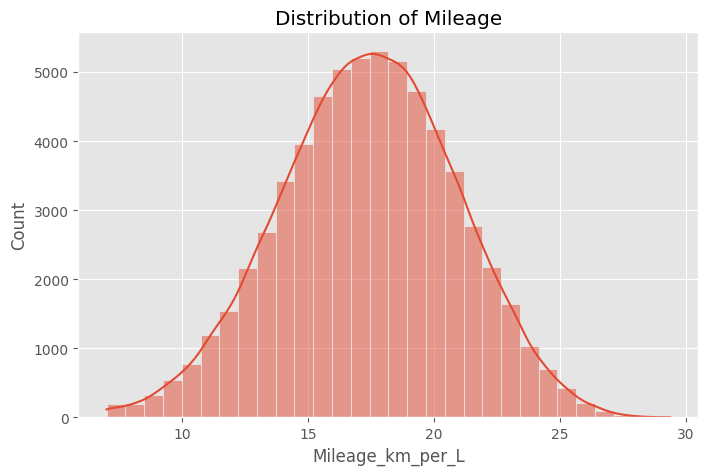

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(df["Mileage_km_per_L"], bins=30, kde=True)

plt.title("Distribution of Mileage")
plt.show()

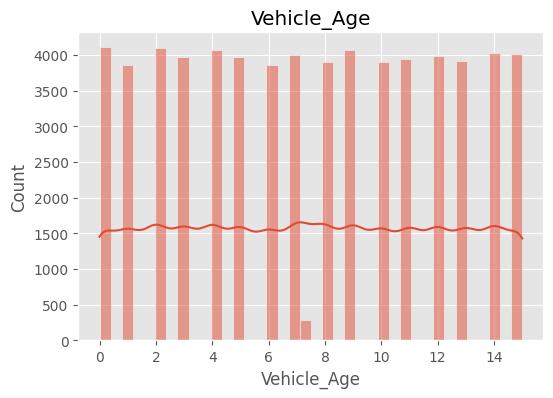

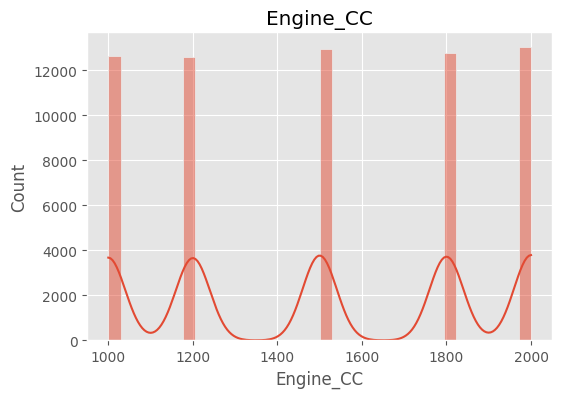

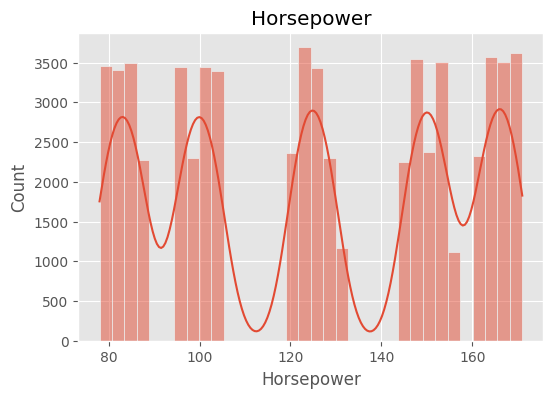

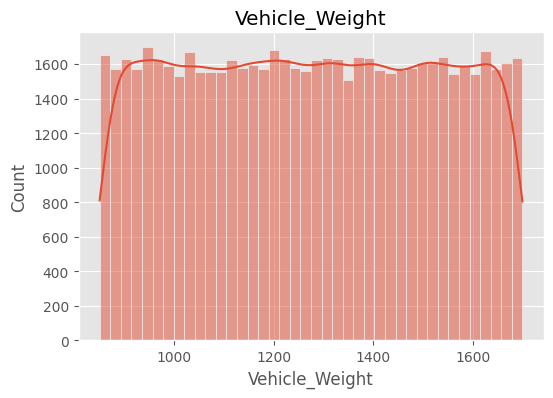

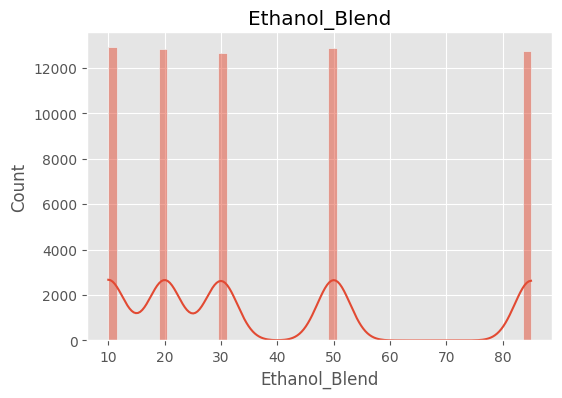

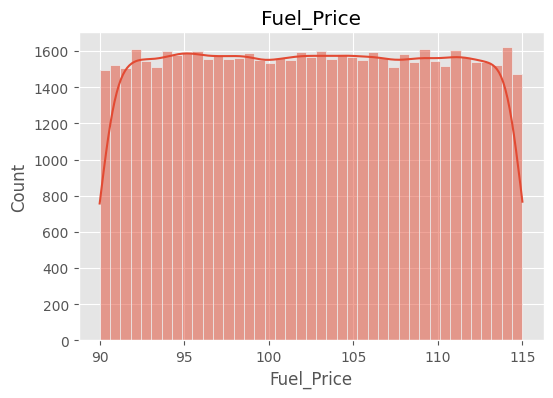

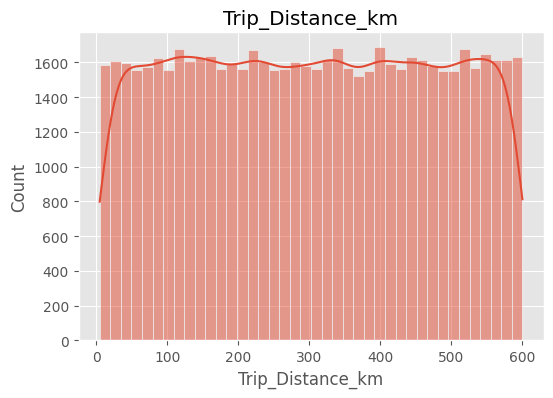

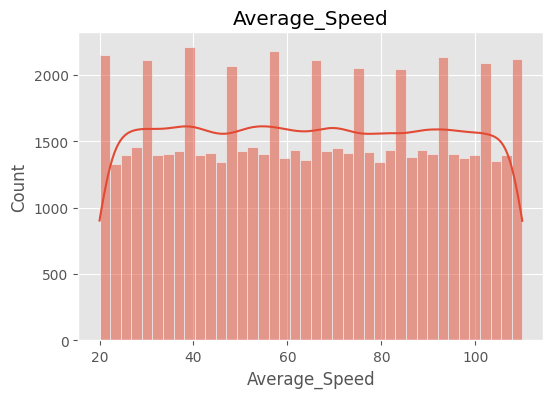

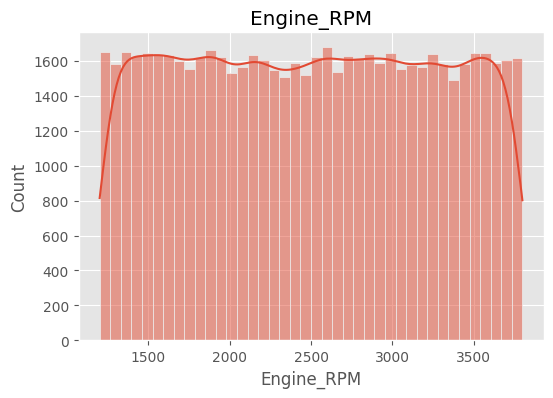

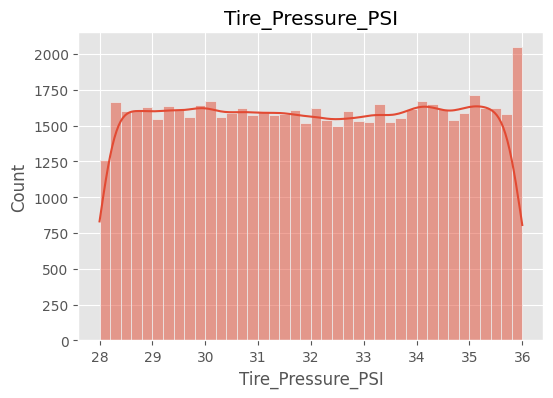

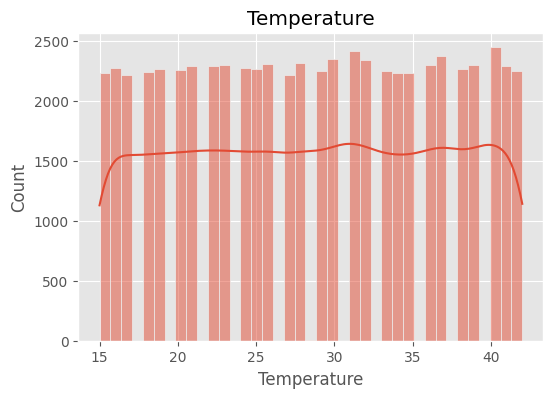

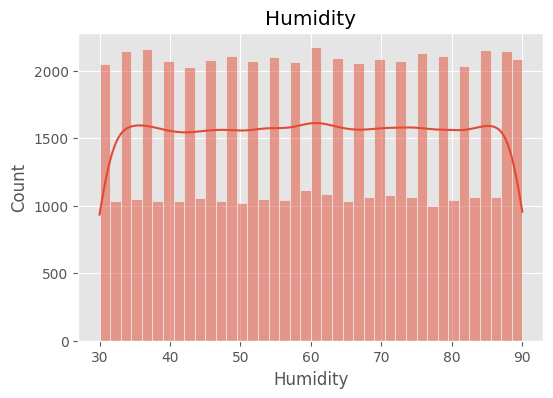

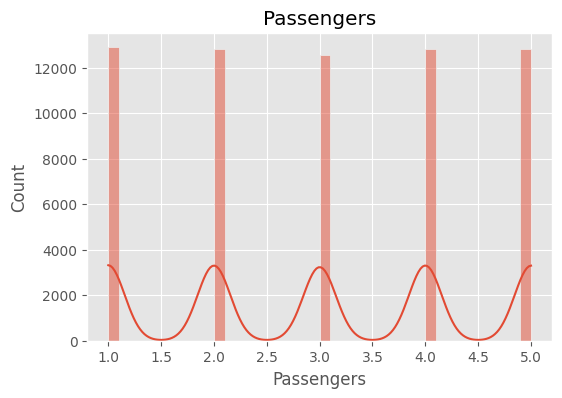

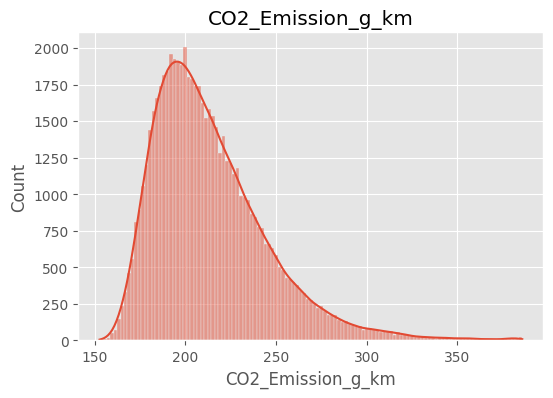

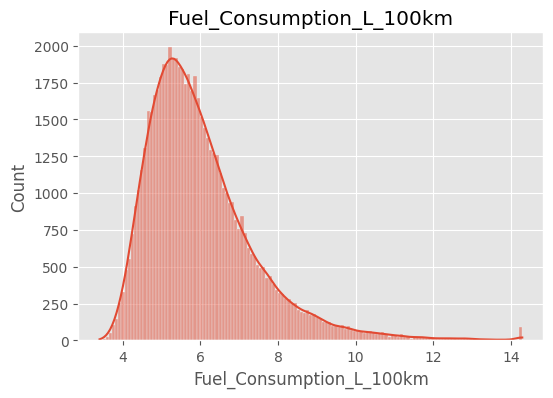

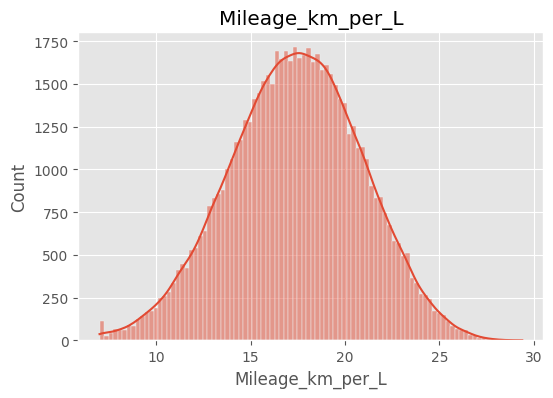

In [5]:
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

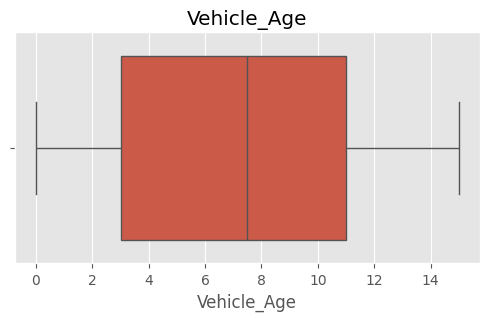

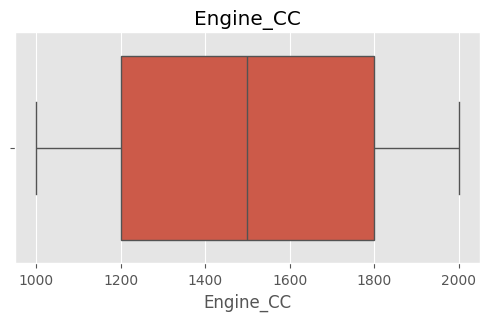

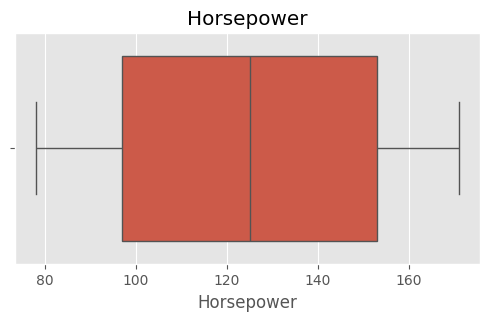

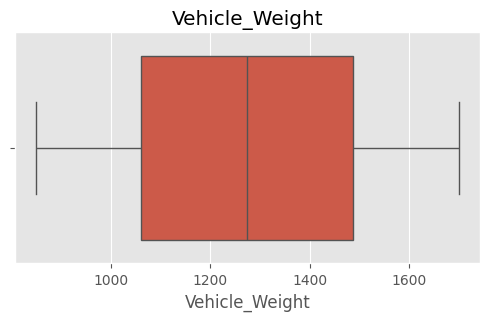

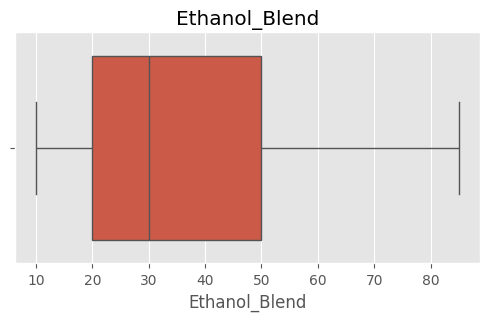

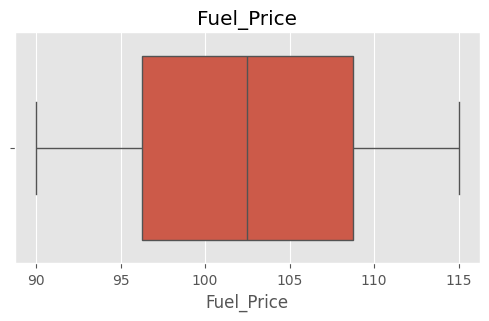

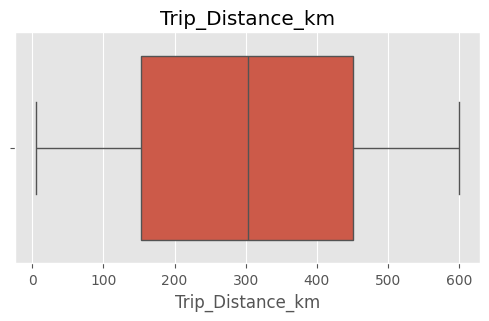

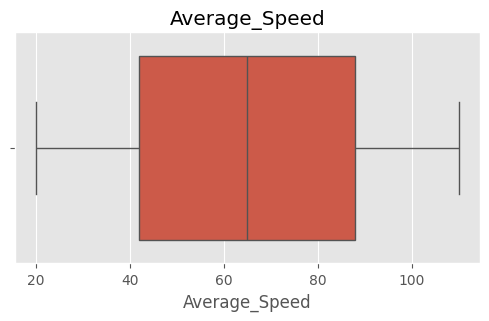

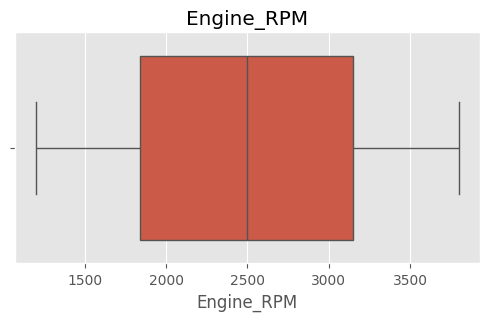

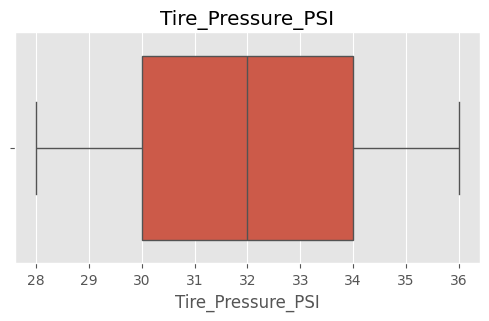

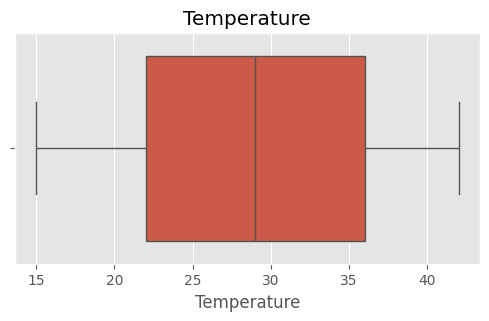

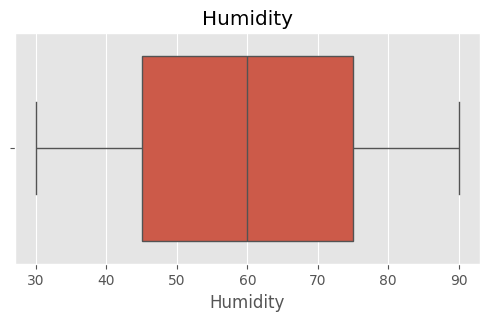

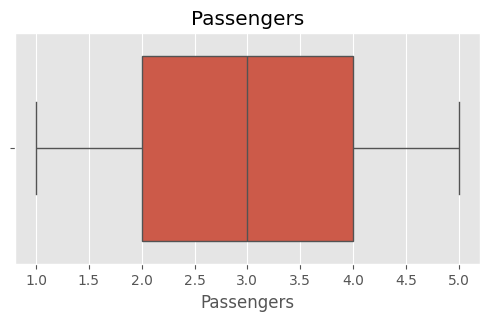

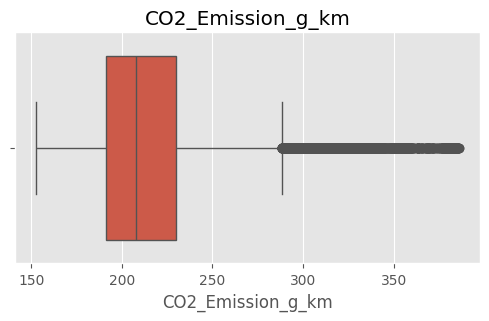

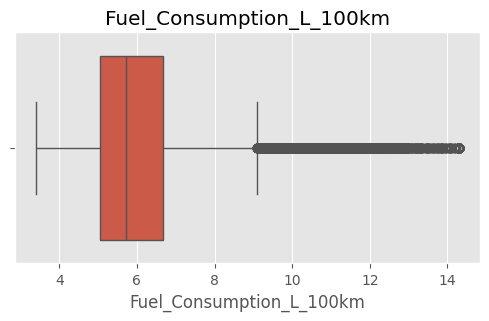

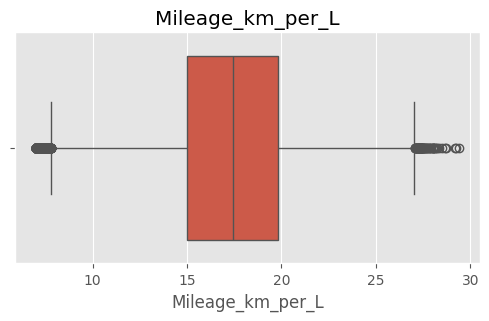

In [6]:
for col in numerical_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

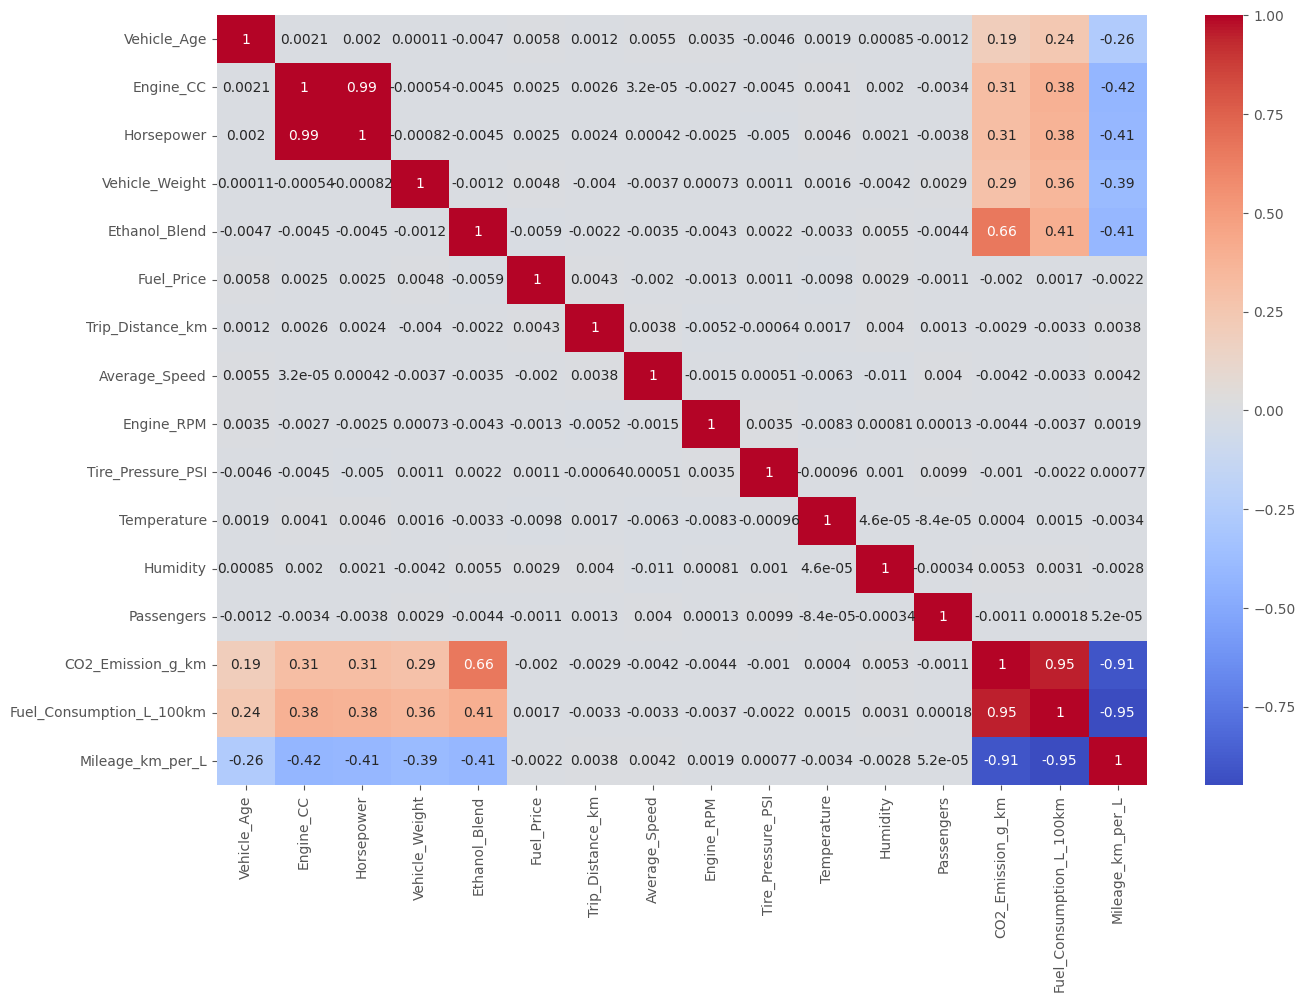

In [7]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [8]:
corr = df.corr(numeric_only=True)["Mileage_km_per_L"]

corr.sort_values(ascending=False)

Mileage_km_per_L            1.000000
Average_Speed               0.004166
Trip_Distance_km            0.003750
Engine_RPM                  0.001950
Tire_Pressure_PSI           0.000766
Passengers                  0.000052
Fuel_Price                 -0.002161
Humidity                   -0.002836
Temperature                -0.003422
Vehicle_Age                -0.258954
Vehicle_Weight             -0.385767
Ethanol_Blend              -0.410120
Horsepower                 -0.413870
Engine_CC                  -0.416189
CO2_Emission_g_km          -0.907547
Fuel_Consumption_L_100km   -0.948989
Name: Mileage_km_per_L, dtype: float64

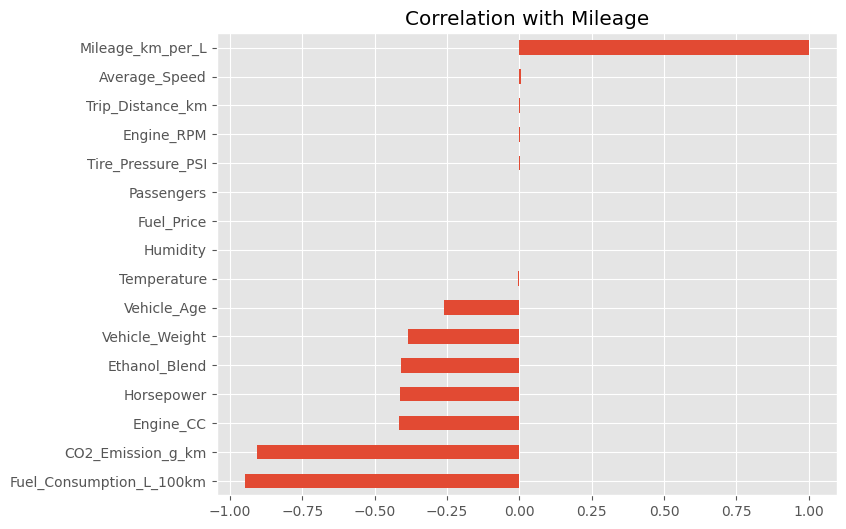

In [9]:
corr.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Correlation with Mileage")

plt.show()

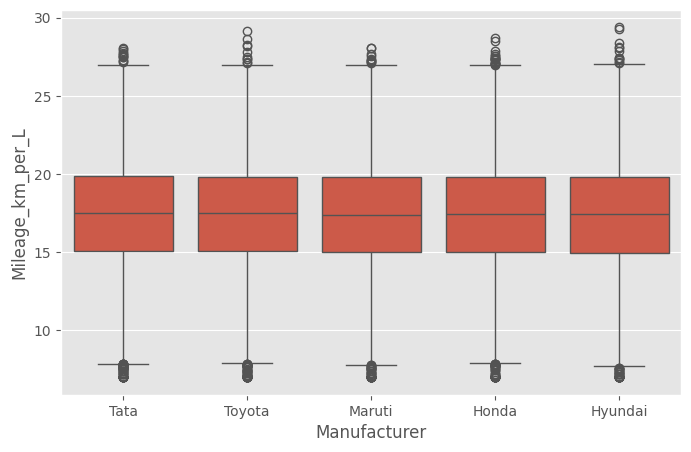

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Manufacturer",
    y="Mileage_km_per_L",
    data=df
)

plt.show()

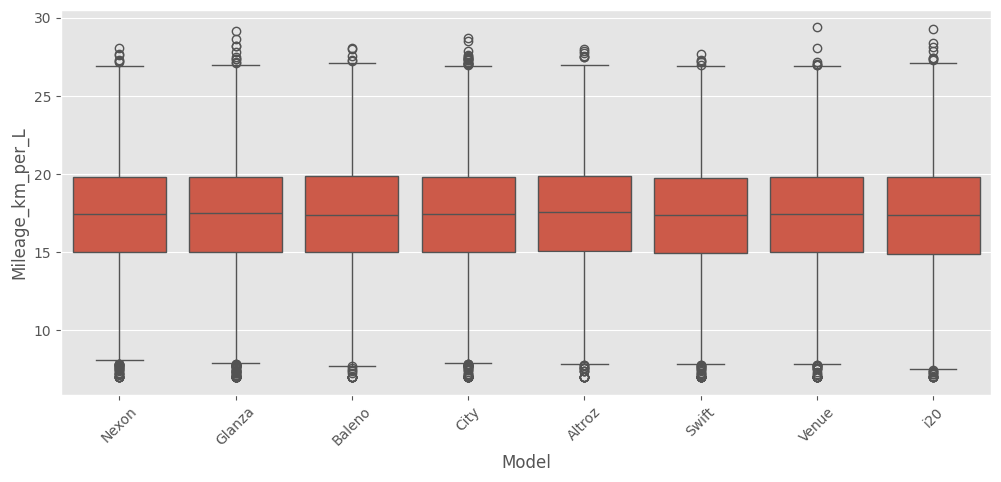

In [11]:
plt.figure(figsize=(12,5))

sns.boxplot(
    x="Model",
    y="Mileage_km_per_L",
    data=df
)

plt.xticks(rotation=45)

plt.show()

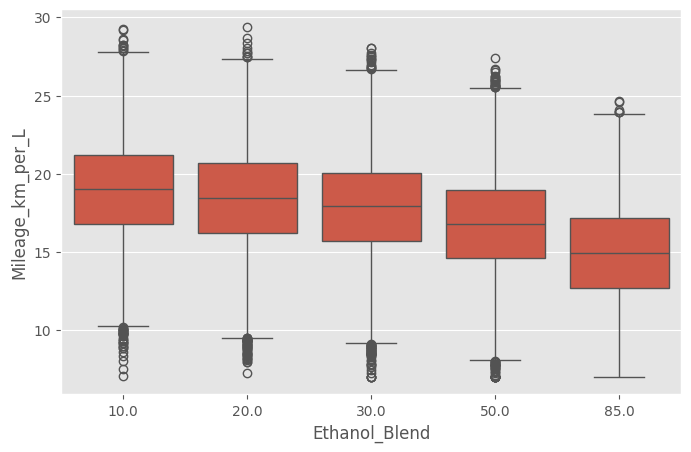

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Ethanol_Blend",
    y="Mileage_km_per_L",
    data=df
)

plt.show()

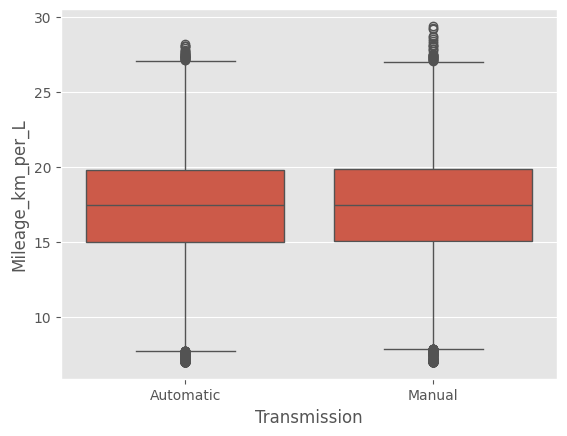

In [13]:
sns.boxplot(
    x="Transmission",
    y="Mileage_km_per_L",
    data=df
)

plt.show()

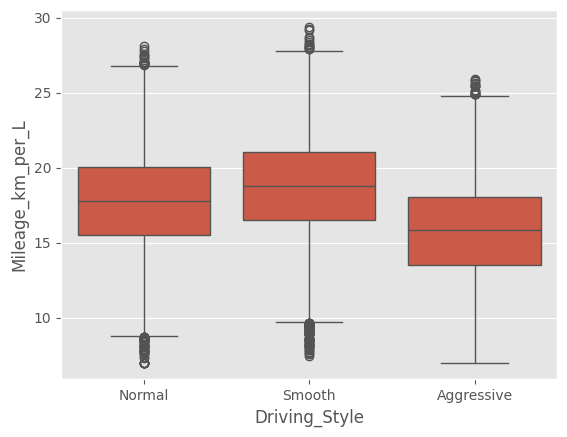

In [14]:
sns.boxplot(
    x="Driving_Style",
    y="Mileage_km_per_L",
    data=df
)

plt.show()

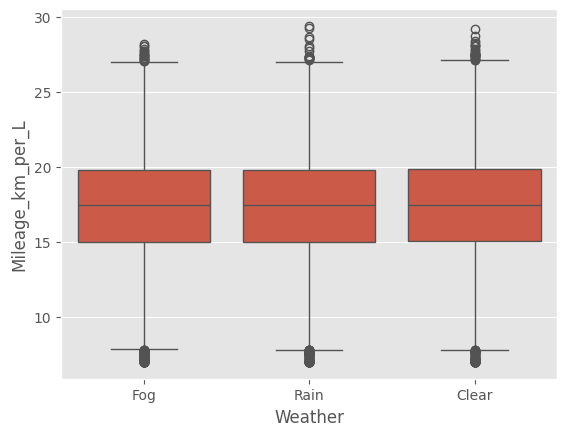

In [15]:
sns.boxplot(
    x="Weather",
    y="Mileage_km_per_L",
    data=df
)

plt.show()

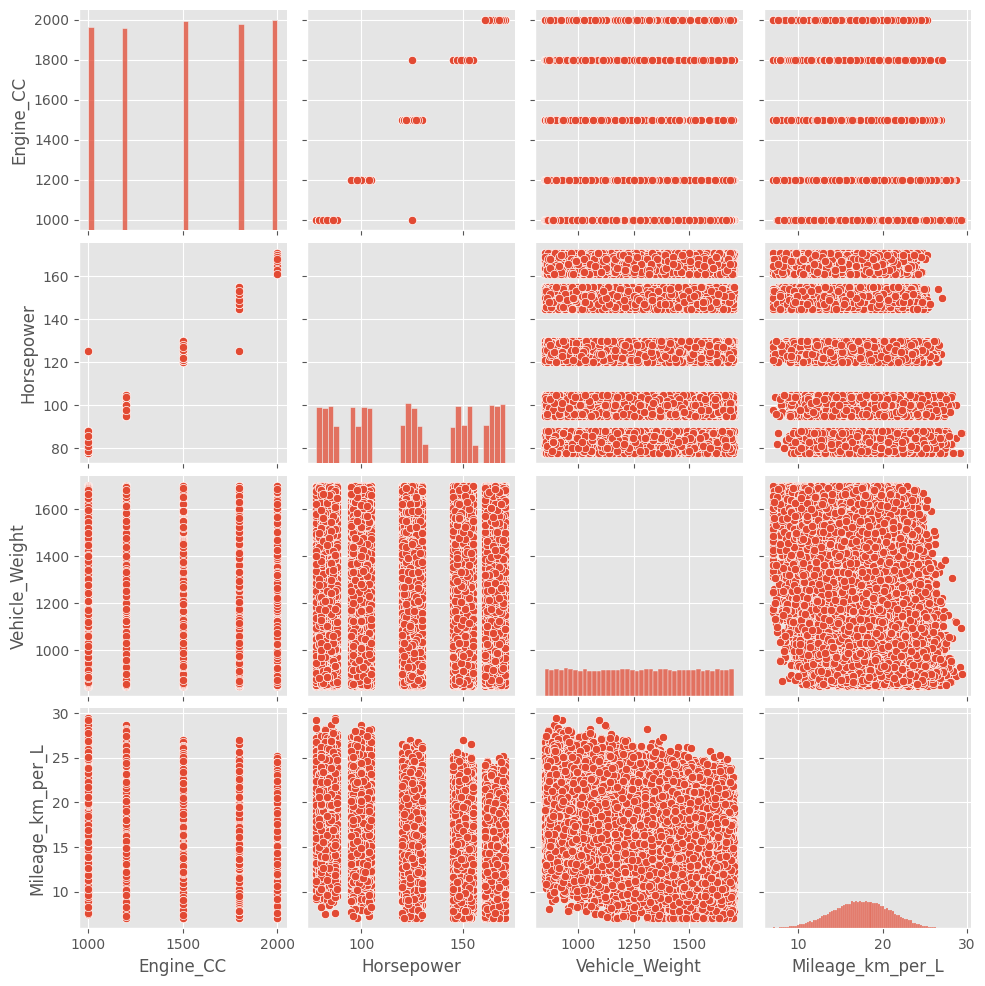

In [16]:
sns.pairplot(
    df[[
        "Engine_CC",
        "Horsepower",
        "Vehicle_Weight",
        "Mileage_km_per_L"
    ]]
)

plt.show()